In [5]:
# 1. Exploración inicial
# Carga `iris_dataset.csv` con Pandas. Muestra las primeras 10 filas, las dimensiones del DataFrame, los
# nombres de las columnas y los tipos de datos. Identifica cuáles variables son numéricas y cuál es

import pandas as pd

df = pd.read_csv("/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/iris_dataset.csv")
df.head(10)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [6]:
print(df.shape)

(150, 5)


In [7]:
print(df.columns.to_list())

['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'species']


In [8]:
print(df.dtypes)

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object


Text(0, 0.5, 'Longitud (cm)')

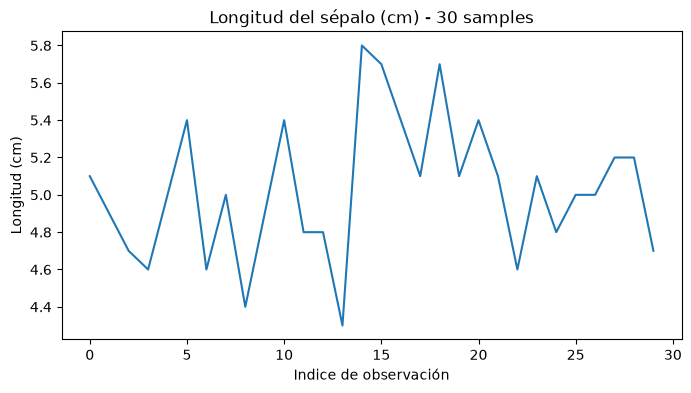

In [16]:
# 2. Línea: secuencia de observaciones
# Grafica con una línea la variable `sepal_length_cm` de las primeras 30 observaciones. Usa el índice de
# la fila como eje X. Agrega título y etiquetas a ambos ejes. Explica en una frase qué representa el orden
# en este caso.
import matplotlib.pyplot as plt

subconjunto = df.loc[0: 29, :]

plt.figure(figsize=(8, 4))
plt.plot(subconjunto.index, subconjunto["sepal_length_cm"])
plt.title("Longitud del sépalo (cm) - 30 samples")
plt.xlabel("Indice de observación")
plt.ylabel("Longitud (cm)")

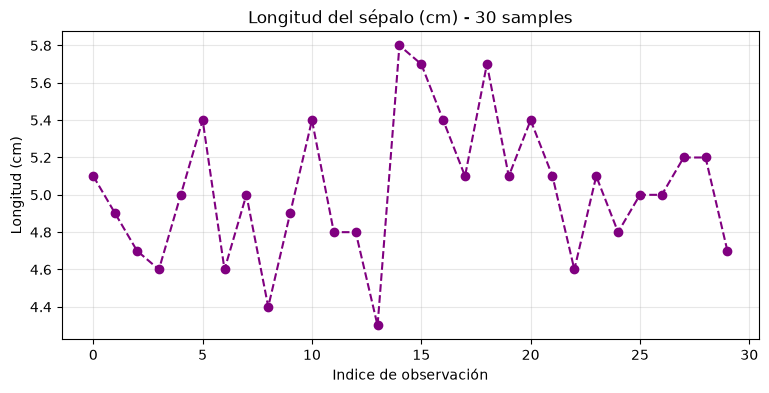

In [25]:
# 3. Línea: personalización
# Repite el gráfico anterior usando marcador circular, línea discontinua y un color diferente. Ajusta el
# tamaño de la figura y agrega una cuadrícula suave.

subconjunto = df.loc[0: 29, :]

plt.figure(figsize=(9, 4))
plt.plot(
    subconjunto.index,
    subconjunto["sepal_length_cm"],
    marker='o',
    linestyle='--',
    color='purple'
)
plt.title("Longitud del sépalo (cm) - 30 samples")
plt.xlabel("Indice de observación")
plt.ylabel("Longitud (cm)")
plt.grid(alpha=0.3)
plt.show()

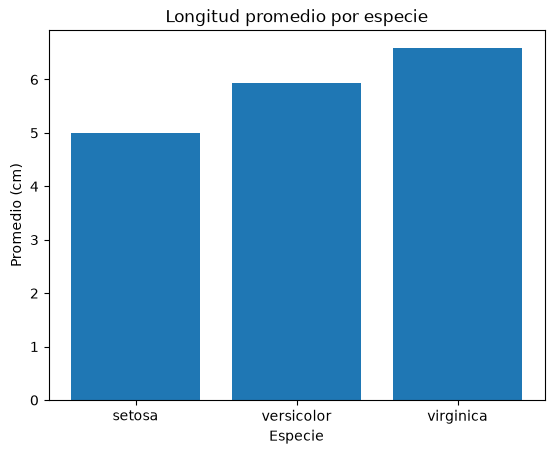

In [28]:
# 4. Barras: promedio por especie
# Calcula el promedio de `sepal_length_cm` para cada `species` y represéntalo con un gráfico de barras
# verticales. Incluye etiquetas de ejes y título.

promedio_sepal_length = df.groupby("species")["sepal_length_cm"].mean()

plt.bar(promedio_sepal_length.index, promedio_sepal_length.values)
plt.title("Longitud promedio por especie")
plt.xlabel("Especie")
plt.ylabel("Promedio (cm)")
plt.show()

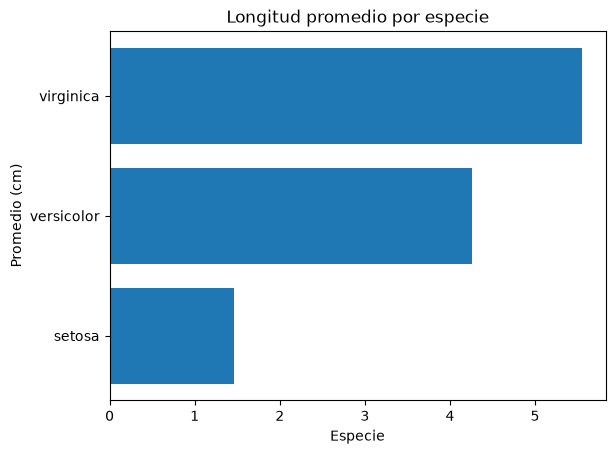

In [35]:
# 5. Barras horizontales
# Calcula el promedio de `petal_length_cm` por especie y crea un gráfico de barras horizontales. Ordena
# las especies de menor a mayor promedio antes de graficar.

promedio_petal_length = df.groupby("species")["petal_length_cm"].mean().sort_values()
promedio_petal_length

plt.barh(promedio_petal_length.index, promedio_petal_length.values)
plt.title("Longitud promedio por especie")
plt.xlabel("Especie")
plt.ylabel("Promedio (cm)")
plt.show()

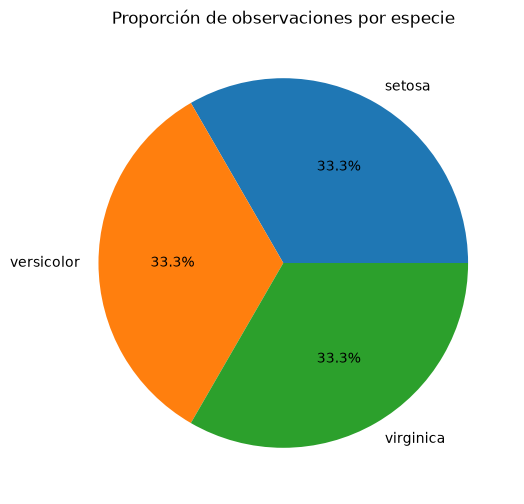

In [38]:
# 6. Pastel: composición del dataset
# Calcula cuántas observaciones existen por especie y represéntalas con un gráfico de pastel. Muestra los
# porcentajes con un decimal. ¿Qué conclusión obtienes sobre el balance del dataset?
counts = df["species"].value_counts()
counts

plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title("Proporción de observaciones por especie")
plt.show()

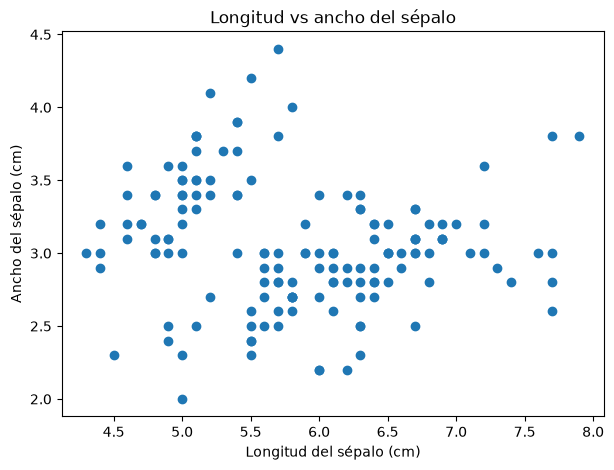

In [39]:
# 7. Dispersión: sépalo
# Crea un scatter plot entre `sepal_length_cm` y `sepal_width_cm`. Agrega título y etiquetas. Describe si
# visualmente parece existir una relación clara entre ambas variables.

plt.figure(figsize=(7, 5))
plt.scatter(df["sepal_length_cm"], df["sepal_width_cm"])
plt.title("Longitud vs ancho del sépalo")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Ancho del sépalo (cm)")
plt.show()

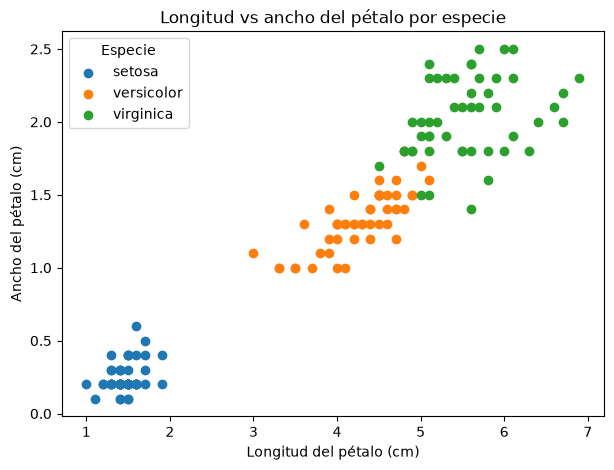

In [40]:
# 8. Dispersión por especie
# Crea un gráfico de dispersión entre `petal_length_cm` y `petal_width_cm`, diferenciando cada especie
# con una serie distinta y una leyenda. No uses Seaborn.

plt.figure(figsize=(7, 5))
for species, group in df.groupby("species"):
    plt.scatter(
        group["petal_length_cm"],
        group["petal_width_cm"],
        label=species,
    )

plt.title("Longitud vs ancho del pétalo por especie")
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.legend(title="Especie")
plt.show()

In [ ]:


# 14. Subplots 2x2
# Crea una cuadrícula 2x2 con un histograma para cada variable numérica: `sepal_length_cm`,
# `sepal_width_cm`, `petal_length_cm` y `petal_width_cm`. Usa `tight_layout()`.
# 15. Leyendas y etiquetas
# Crea nuevamente el scatter de `petal_length_cm` vs. `petal_width_cm` por especie. Esta vez agrega
# título general, etiquetas de ejes, leyenda y cuadrícula. La figura debe ser autoexplicativa sin leer el
# código.
# 16. Estilos
# Aplica temporalmente el estilo `ggplot` a un gráfico de barras con el promedio de `sepal_width_cm` por
# especie. Al terminar, restaura el estilo `default` para no afectar gráficos posteriores.
# 17. POO: Figure y Axes
# Usando exclusivamente el enfoque orientado a objetos (`fig, ax = plt.subplots()`), crea un gráfico de
# barras con el promedio de `petal_width_cm` por especie. Configura título y etiquetas con métodos de
# `Axes`.
# 18. POO: múltiples Axes
# Con `fig, axes = plt.subplots(1, 3)`, crea un boxplot independiente de `petal_length_cm` para cada
# especie. Cada panel debe tener el nombre de la especie como título y la misma escala en Y.
# 19. Gráfico principal + gráfico insertado
# Usa `Figure.add_axes()` para crear un scatter principal de `petal_length_cm` vs. `petal_width_cm` y un
# eje pequeño insertado que muestre un histograma de `petal_length_cm`. Añade títulos apropiados.
# 20. Mini dashboard final
# Construye una figura 2x2 que resuma el dataset con cuatro visualizaciones diferentes: (1) barras del
# promedio de longitud de sépalo por especie, (2) scatter de longitud vs. ancho de pétalo por especie, (3)
# histograma de ancho de sépalo y (4) boxplot de longitud de pétalo por especie. Usa POO, títulos claros,
# leyendas cuando correspondan y `tight_layout()`.